# Actividad 1. Segmentación de clientes mediante Aprendizaje No Supervisado

Versión actualizada para incorporar el género como variable de análisis, limpieza y comparación.

## Objetivo

Aplicar técnicas de clustering para identificar grupos homogéneos de clientes a partir de variables demográficas y de consumo, y validar si el género modifica la interpretación del perfilamiento.

## Entregables esperados

- Exploración inicial del dataset.
- Limpieza y procesamiento de datos.
- Análisis visual con comparaciones por género.
- Entrenamiento de al menos dos algoritmos de clustering.
- Reporte comparativo con y sin género.

## 1. Configuración inicial

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "Mall_Customers.csv"
FIGURES_DIR = BASE_DIR / "figuras_genero"
FIGURES_DIR.mkdir(exist_ok=True)

## 2. Carga del dataset

In [2]:
df_raw = pd.read_csv(DATASET_PATH)
df_raw.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploración inicial del conjunto de datos

In [3]:
print("Shape:", df_raw.shape)
print("Columnas:", df_raw.columns.tolist())
df_raw.info()
df_raw.describe(include="all")

Shape: (200, 5)
Columnas: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## 4. Análisis exploratorio visual

En esta versión se añade una vista específica por género para validar si afecta la lectura de edad, ingreso y gasto.

C:\Users\FoodLovers\AppData\Local\Temp\ipykernel_32748\1899793906.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x="Genre", ax=axes.flat[3], palette="Set2")


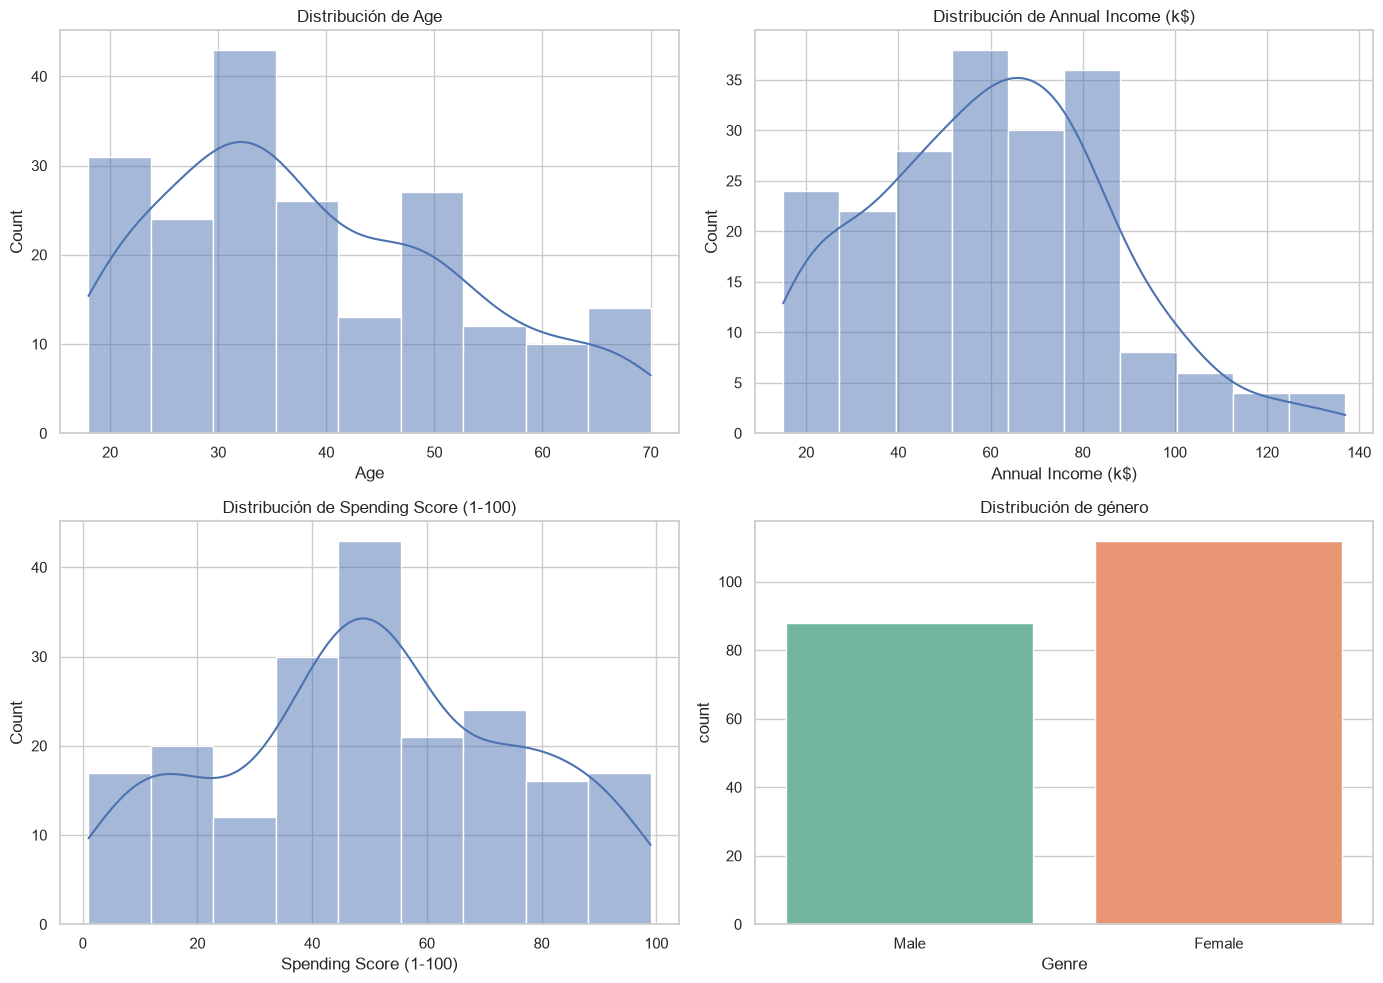

In [4]:
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat[:3], numeric_cols):
    sns.histplot(df_raw[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribución de {col}")

sns.countplot(data=df_raw, x="Genre", ax=axes.flat[3], palette="Set2")
axes.flat[3].set_title("Distribución de género")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribuciones_iniciales.png", dpi=300)
plt.show()

C:\Users\FoodLovers\AppData\Local\Temp\ipykernel_32748\3543472457.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="Genre", y="Age", palette="Set3")


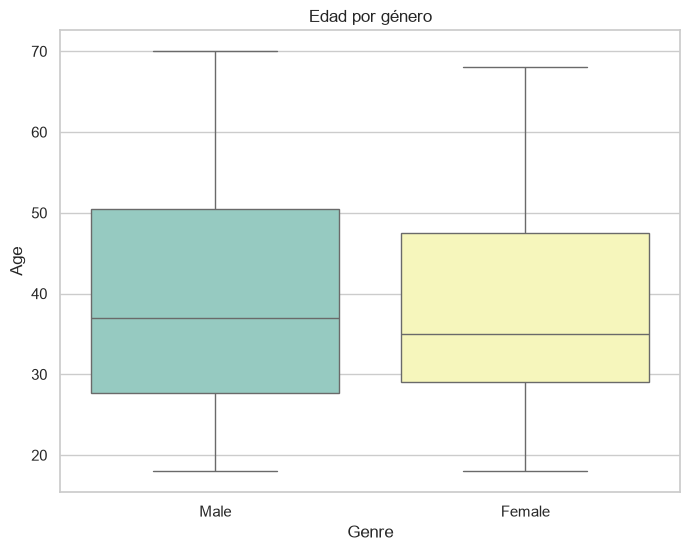

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_raw, x="Genre", y="Age", palette="Set3")
plt.title("Edad por género")
plt.savefig(FIGURES_DIR / "edad_por_genero.png", dpi=300)
plt.show()

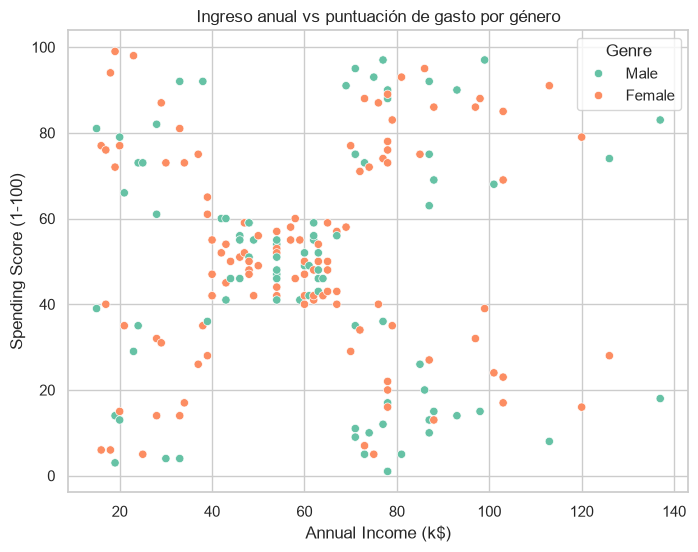

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_raw,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Genre",
    palette="Set2"
)
plt.title("Ingreso anual vs puntuación de gasto por género")
plt.savefig(FIGURES_DIR / "ingreso_gasto_genero.png", dpi=300)
plt.show()

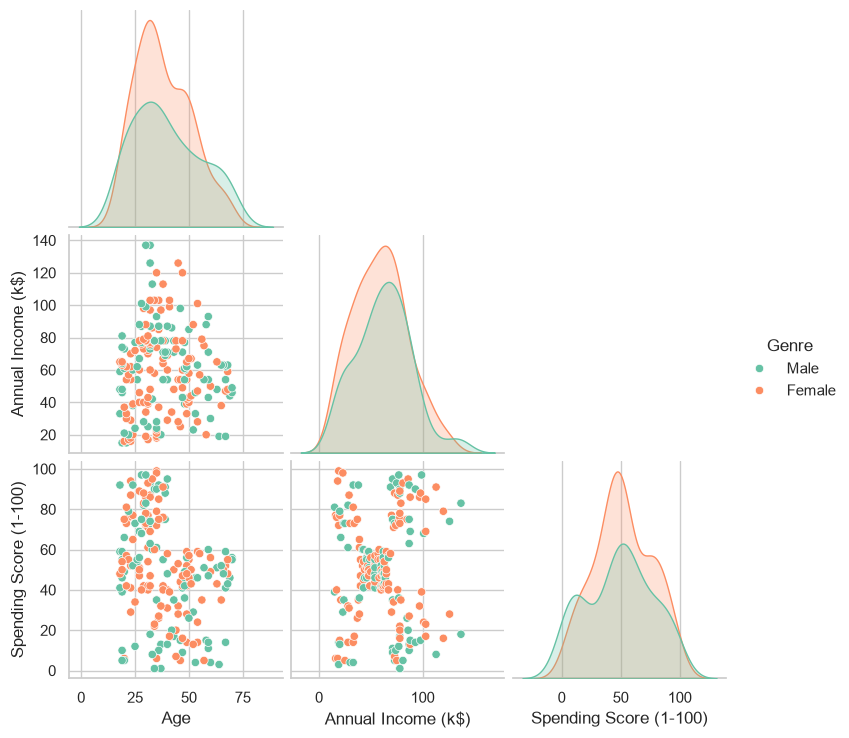

In [7]:
pairplot = sns.pairplot(df_raw, vars=numeric_cols, hue="Genre", corner=True, palette="Set2")
pairplot.savefig(FIGURES_DIR / "pairplot_genero.png", dpi=300)
plt.show()

## 5. Preprocesamiento

Se limpia el dato de género, se convierte `Female` a `True` y `Male` a `False`, y se conserva una versión binaria para análisis y modelado.

In [8]:
df = df_raw.copy()
df.columns = [col.strip() for col in df.columns]
df["Genero"] = df["Genre"].str.strip().str.lower().map({"female": True, "male": False})
df["Genero_binario"] = df["Genero"].astype(int)
df["Genero_label"] = df["Genero"].map({True: "Female", False: "Male"})
df = df.drop(columns=["Genre"])
df.isnull().sum()

CustomerID                0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Genero                    0
Genero_binario            0
Genero_label              0
dtype: int64

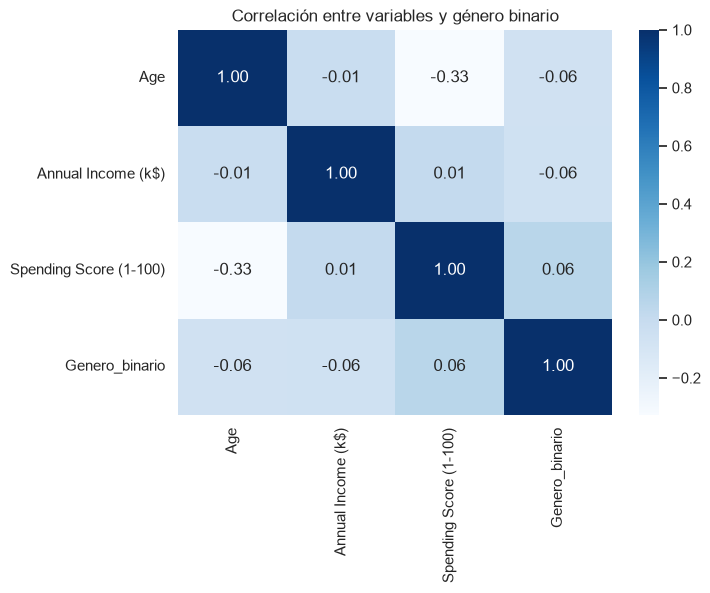

In [9]:
corr_df = df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Genero_binario"]].copy()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlación entre variables y género binario")
plt.savefig(FIGURES_DIR / "corr_variables_genero.png", dpi=300)
plt.show()

## 6. Búsqueda del número óptimo de clusters para K-Means

Se evalúan dos escenarios: sin género y con género. Así se valida si la variable añade señal útil al reporte.

In [10]:
features_base = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
features_gender = features_base + ["Genero_binario"]

X_base = df[features_base].copy()
X_gender = df[features_gender].copy()

scaler_base = StandardScaler()
X_base_scaled = scaler_base.fit_transform(X_base)

scaler_gender = StandardScaler()
X_gender_scaled = scaler_gender.fit_transform(X_gender)

k_values = range(2, 11)

metrics_base = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_base_scaled)
    metrics_base.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_base_scaled, labels)
    })

metrics_base = pd.DataFrame(metrics_base)
metrics_base

,k,inertia,silhouette
0,2,389.386189,0.335472
1,3,295.212246,0.357793
2,4,205.225147,0.403958
3,5,168.247580,0.416643
4,6,133.868421,0.428417
5,7,117.011555,0.417232
6,8,103.873292,0.408207
7,9,93.092891,0.417693
8,10,82.385154,0.406554


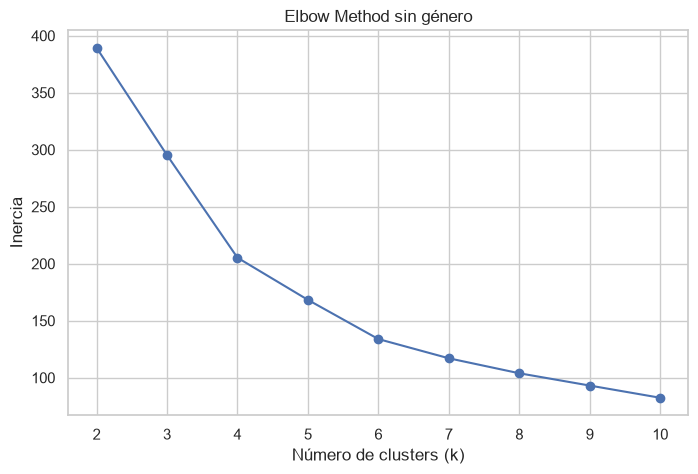

In [11]:
plt.plot(metrics_base["k"], metrics_base["inertia"], marker="o")
plt.title("Elbow Method sin género")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.savefig(FIGURES_DIR / "elbow_sin_genero.png", dpi=300)
plt.show()

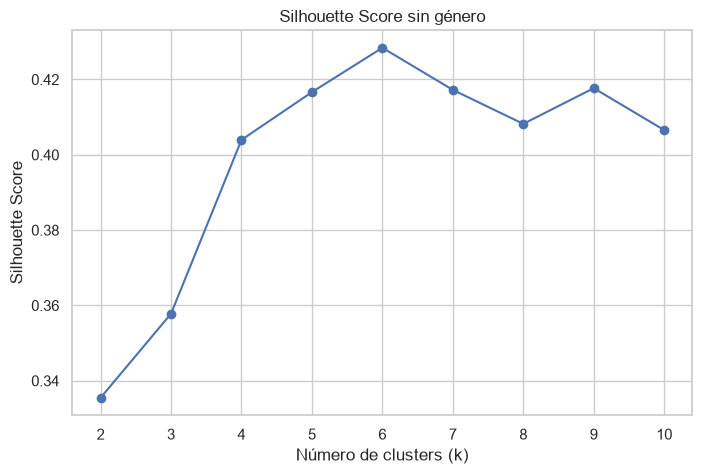

In [12]:
plt.plot(metrics_base["k"], metrics_base["silhouette"], marker="o")
plt.title("Silhouette Score sin género")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.savefig(FIGURES_DIR / "silhouette_sin_genero.png", dpi=300)
plt.show()

## 7. Entrenamiento del modelo K-Means final

In [13]:
best_k_base = int(metrics_base.loc[metrics_base["silhouette"].idxmax(), "k"])
kmeans_base = KMeans(n_clusters=best_k_base, random_state=42, n_init=10)
df["cluster_kmeans_base"] = kmeans_base.fit_predict(X_base_scaled)
df[["cluster_kmeans_base"] + features_base + ["Genero_label"]].head()

,cluster_kmeans_base,Age,Annual Income (k$),Spending Score (1-100),Genero_label
0,4,19,15,39,Male
1,4,21,15,81,Male
2,5,20,16,6,Female
3,4,23,16,77,Female
4,5,31,17,40,Female


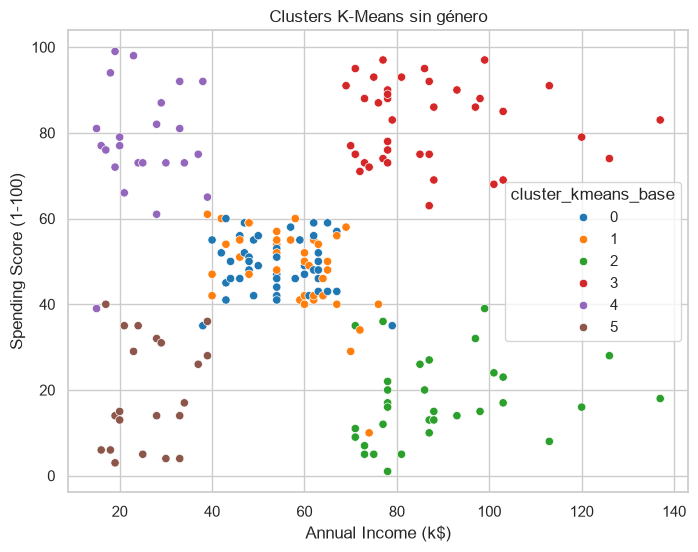

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="cluster_kmeans_base",
    palette="tab10"
)
plt.title("Clusters K-Means sin género")
plt.savefig(FIGURES_DIR / "kmeans_sin_genero.png", dpi=300)
plt.show()

## 8. K-Means con género como variable adicional

In [15]:
metrics_gender = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_gender_scaled)
    metrics_gender.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_gender_scaled, labels)
    })

metrics_gender = pd.DataFrame(metrics_gender)
metrics_gender

,k,inertia,silhouette
0,2,588.802677,0.251815
1,3,476.787554,0.259513
2,4,388.717861,0.298397
3,5,331.309884,0.304060
4,6,276.411760,0.331074
5,7,236.204947,0.357377
6,8,199.750461,0.387993
7,9,174.235477,0.403092
8,10,152.029834,0.420764


In [16]:
best_k_gender = int(metrics_gender.loc[metrics_gender["silhouette"].idxmax(), "k"])
kmeans_gender = KMeans(n_clusters=best_k_gender, random_state=42, n_init=10)
df["cluster_kmeans_genero"] = kmeans_gender.fit_predict(X_gender_scaled)

silhouette_base = silhouette_score(X_base_scaled, df["cluster_kmeans_base"])
silhouette_gender = silhouette_score(X_gender_scaled, df["cluster_kmeans_genero"])

print("Silhouette sin género:", silhouette_base)
print("Silhouette con género:", silhouette_gender)

Silhouette sin género: 0.4284167762892593
Silhouette con género: 0.42076374869477745


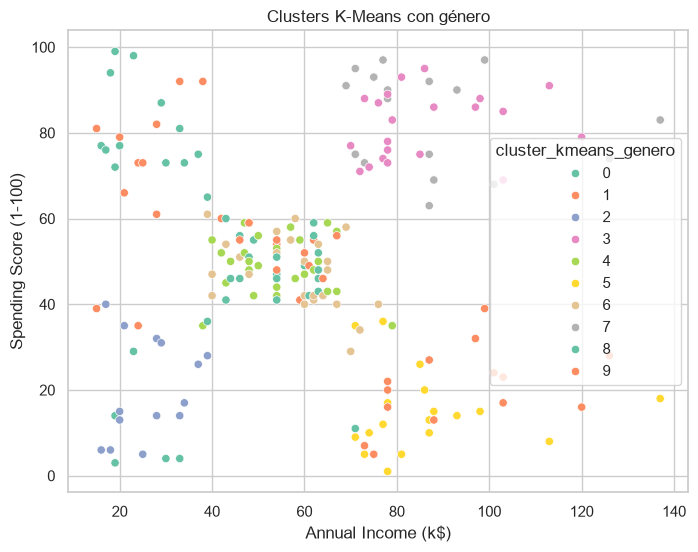

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="cluster_kmeans_genero",
    palette="Set2"
)
plt.title("Clusters K-Means con género")
plt.savefig(FIGURES_DIR / "kmeans_con_genero.png", dpi=300)
plt.show()

In [18]:
gender_mix_base = pd.crosstab(df["cluster_kmeans_base"], df["Genero_label"], normalize="index").round(2)
gender_mix_gender = pd.crosstab(df["cluster_kmeans_genero"], df["Genero_label"], normalize="index").round(2)

display(gender_mix_base)
display(gender_mix_gender)

Genero_label,Female,Male
cluster_kmeans_base,,
0,0.58,0.42
1,0.64,0.36
2,0.42,0.58
3,0.54,0.46
4,0.57,0.43
5,0.62,0.38


Genero_label,Female,Male
cluster_kmeans_genero,,
0,0.00,1.00
1,0.00,1.00
2,0.93,0.07
3,1.00,0.00
4,1.00,0.00
5,0.00,1.00
6,1.00,0.00
7,0.00,1.00
8,1.00,0.00


## 9. Segundo algoritmo de clustering

In [19]:
agg_base = AgglomerativeClustering(n_clusters=best_k_base)
agg_gender = AgglomerativeClustering(n_clusters=best_k_gender)

df["cluster_agg_base"] = agg_base.fit_predict(X_base_scaled)
df["cluster_agg_genero"] = agg_gender.fit_predict(X_gender_scaled)

silhouette_agg_base = silhouette_score(X_base_scaled, df["cluster_agg_base"])
silhouette_agg_gender = silhouette_score(X_gender_scaled, df["cluster_agg_genero"])

print("Silhouette Agglomerative sin género:", silhouette_agg_base)
print("Silhouette Agglomerative con género:", silhouette_agg_gender)

Silhouette Agglomerative sin género: 0.4201169558789579
Silhouette Agglomerative con género: 0.4176254448686808


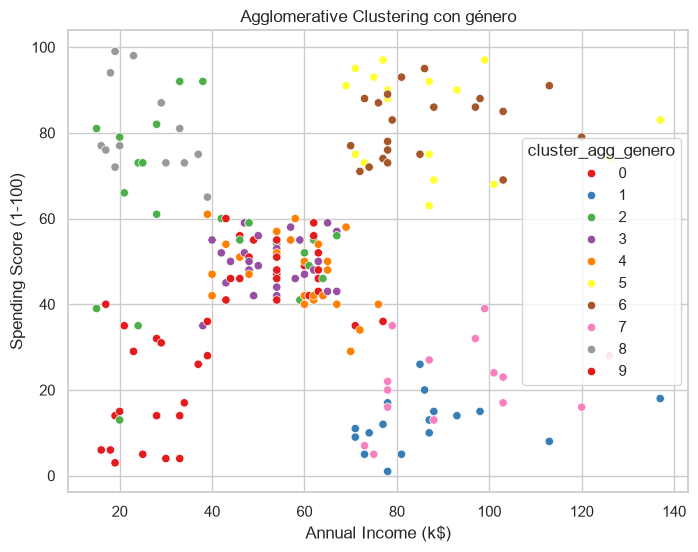

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="cluster_agg_genero",
    palette="Set1"
)
plt.title("Agglomerative Clustering con género")
plt.savefig(FIGURES_DIR / "agg_con_genero.png", dpi=300)
plt.show()

## 10. Resumen e interpretación de clusters

In [21]:
summary_kmeans_base = df.groupby("cluster_kmeans_base")[features_base].mean().round(2)
summary_kmeans_base["size"] = df["cluster_kmeans_base"].value_counts().sort_index()
summary_kmeans_base["female_share"] = df.groupby("cluster_kmeans_base")["Genero_binario"].mean().round(2)

summary_kmeans_gender = df.groupby("cluster_kmeans_genero")[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Genero_binario"]].mean().round(2)
summary_kmeans_gender["size"] = df["cluster_kmeans_genero"].value_counts().sort_index()

display(summary_kmeans_base)
display(summary_kmeans_gender)

summary_kmeans_base.to_csv(FIGURES_DIR / "resumen_kmeans_sin_genero.csv")
summary_kmeans_gender.to_csv(FIGURES_DIR / "resumen_kmeans_con_genero.csv")

,Age,Annual Income (k$),Spending Score (1-100),size,female_share
cluster_kmeans_base,,,,,
0,56.33,54.27,49.07,45,0.58
1,26.79,57.10,48.13,39,0.64
2,41.94,88.94,16.97,33,0.42
3,32.69,86.54,82.13,39,0.54
4,25.00,25.26,77.61,23,0.57
5,45.52,26.29,19.38,21,0.62


,Age,Annual Income (k$),Spending Score (1-100),Genero_binario,size
cluster_kmeans_genero,,,,,
0,58.85,48.69,39.85,0.00,26
1,25.25,41.25,60.92,0.00,24
2,41.21,26.07,20.14,0.93,14
3,32.19,86.05,81.67,1.00,21
4,54.15,54.23,48.96,1.00,26
5,38.47,85.89,14.21,0.00,19
6,27.96,57.36,47.12,1.00,25
7,33.28,87.11,82.67,0.00,18
8,25.46,25.69,80.54,1.00,13


In [22]:
summary_agg_base = df.groupby("cluster_agg_base")[features_base].mean().round(2)
summary_agg_base["size"] = df["cluster_agg_base"].value_counts().sort_index()
summary_agg_base["female_share"] = df.groupby("cluster_agg_base")["Genero_binario"].mean().round(2)

summary_agg_gender = df.groupby("cluster_agg_genero")[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Genero_binario"]].mean().round(2)
summary_agg_gender["size"] = df["cluster_agg_genero"].value_counts().sort_index()

display(summary_agg_base)
display(summary_agg_gender)

summary_agg_base.to_csv(FIGURES_DIR / "resumen_agg_sin_genero.csv")
summary_agg_gender.to_csv(FIGURES_DIR / "resumen_agg_con_genero.csv")

,Age,Annual Income (k$),Spending Score (1-100),size,female_share
cluster_agg_base,,,,,
0,27.38,57.51,45.84,45,0.60
1,56.40,55.29,48.36,45,0.53
2,32.69,86.54,82.13,39,0.54
3,43.89,91.29,16.68,28,0.50
4,44.32,25.77,20.27,22,0.59
5,24.81,25.62,80.24,21,0.62


,Age,Annual Income (k$),Spending Score (1-100),Genero_binario,size
cluster_agg_genero,,,,,
0,56.55,50.03,41.34,0.0,29
1,38.83,86.39,11.67,0.0,18
2,24.57,39.22,59.65,0.0,23
3,54.08,53.24,49.52,1.0,25
4,27.96,57.36,47.12,1.0,25
5,33.28,87.11,82.67,0.0,18
6,32.19,86.05,81.67,1.0,21
7,44.60,92.33,21.60,1.0,15
8,25.46,25.69,80.54,1.0,13


## 11. Comparación de algoritmos

Aquí se deja una comparación directa entre los modelos con y sin género para evaluar si la variable aporta separación útil o solo ruido.

In [23]:
comparison = pd.DataFrame([
    {
        "Metodo": "K-Means sin género",
        "Numero_clusters": df["cluster_kmeans_base"].nunique(),
        "Silhouette": silhouette_base,
        "Observacion": "Referencia base"
    },
    {
        "Metodo": "K-Means con género",
        "Numero_clusters": df["cluster_kmeans_genero"].nunique(),
        "Silhouette": silhouette_gender,
        "Observacion": "Valida el impacto del género"
    },
    {
        "Metodo": "Agglomerative sin género",
        "Numero_clusters": df["cluster_agg_base"].nunique(),
        "Silhouette": silhouette_agg_base,
        "Observacion": "Referencia jerárquica base"
    },
    {
        "Metodo": "Agglomerative con género",
        "Numero_clusters": df["cluster_agg_genero"].nunique(),
        "Silhouette": silhouette_agg_gender,
        "Observacion": "Jerárquico con variable de género"
    }
]).round(3)

display(comparison)
comparison.to_csv(FIGURES_DIR / "comparacion_algoritmos_genero.csv", index=False)

,Metodo,Numero_clusters,Silhouette,Observacion
0,K-Means sin género,6,0.428,Referencia base
1,K-Means con género,10,0.421,Valida el impacto del género
2,Agglomerative sin género,6,0.420,Referencia jerárquica base
3,Agglomerative con género,10,0.418,Jerárquico con variable de género


## 12. Conclusiones

Esta versión deja el género procesado como variable booleana y abre dos lecturas: la segmentación clásica sin género y la segmentación extendida con género. La comparación final debe usarse para decidir si el género mejora la separación de clusters o solo añade complejidad al reporte.